# 江南江北风电出力预测与实际数据&风速气象数据的关系
气象数据说明：
- 分别来自三家不同的公司ANT、OBS、CLD
- 江南以苏州4月的气象数据为例，格点为1h
- 江北以盐城4月的气象数据为例，格点为1h
   
光伏出力数据说明：
- 分为日前预测出力与实际运行出力2类
- 取1h內4个统计值的平均，即每天有24个数据  

## 数据预处理

### 风速

In [1]:
import pandas as pd

SU_ANT = pd.read_excel('/Users/huyang/Desktop/4月江南气象/ANT苏州4月.xlsx',
                       usecols=['日期', '小时','80米风速(m/s)']).set_index(['日期', '小时'])

SU_OBS = pd.read_excel('/Users/huyang/Desktop/4月江南气象/OBS苏州4月.xlsx',
                       usecols=['日期', '小时','80米风速(m/s)']).set_index(['日期', '小时'])

SU_CLD = pd.read_excel('/Users/huyang/Desktop/4月江南气象/CLD苏州4月.xlsx',
                       usecols=['日期', '小时','80米风速(m/s)']).set_index(['日期', '小时'])

YAN_ANT = pd.read_excel('/Users/huyang/Desktop/4月江北气象/ANT盐城4月.xlsx',
                       usecols=['日期', '小时','80米风速(m/s)']).set_index(['日期', '小时'])

YAN_OBS = pd.read_excel('/Users/huyang/Desktop/4月江北气象/OBS盐城4月.xlsx',
                       usecols=['日期', '小时','80米风速(m/s)']).set_index(['日期', '小时'])

YAN_CLD = pd.read_excel('/Users/huyang/Desktop/4月江北气象/CLD盐城4月.xlsx',
                       usecols=['日期', '小时','80米风速(m/s)']).set_index(['日期', '小时'])
SU_ANT

80米风速(m/s)
日期         小时               
2026/04/01 01:00       1.240
           02:00       0.847
           03:00       1.379
           04:00       2.151
           05:00       2.151
...                      ...
2026/04/30 20:00       4.086
           21:00       3.937
           22:00       3.663
           23:00       3.766
           24:00       3.711

[720 rows x 1 columns]

### 风电出力

In [10]:
import pandas as pd

file_paths = [f'/Users/huyang/Desktop/2026年4月可视化图表/江苏现货价格可视化图表202604{i:02d}.xlsx' for i in range(1, 31)]
all_dfs = []

for i, file_path in enumerate(file_paths, start=1):
    df = pd.read_excel(
        file_path,
        sheet_name='电网运行信息',
        usecols='F,K,L,AL,AM',
        skiprows=2,  # 跳过前2行
        header=None   # 不将任何行作为列名，因为数据从第3行开始
    )
    
    # 统一列名
    df.columns = ['时刻', '预测风电江南', '预测风电江北', '实际风电江南', '实际风电江北']

    df.dropna(subset=['时刻'], inplace=True)
    df['时刻'] = df['时刻'].astype(str).str.strip().str[-8:]  # 取最后8个字符
    df['时刻'] = df['时刻'].str[:5]  # 截取HH:MM

     # 去除均值行
    df = df[~df['时刻'].str.contains('均值|平均|avg', case=False, na=False)]
    
    # 设置多层索引（表号, 时刻）
    df['日期'] = f'2026/04/{i:02d}'
    df.set_index(['日期', '时刻'], inplace=True)
    
    all_dfs.append(df)

result_df = pd.concat(all_dfs)
result_df

预测风电江南    预测风电江北  实际风电江南    实际风电江北
日期         时刻                                       
2026/04/01 00:15   11.29   3143.14   -0.07   1734.69
           00:30   10.91   3189.88   -0.06   1869.51
           00:45   10.53   3239.45   -0.08   2019.81
           01:00   10.14   3285.74   -0.06   2112.35
           01:15    9.90   3308.34   -0.07   2108.88
...                  ...       ...     ...       ...
2026/04/30 23:00   20.91  12518.24    3.80   9557.01
           23:15   20.71  12982.20    3.78  10158.72
           23:30   20.43  13406.80    3.53  10483.17
           23:45   20.18  13806.38    3.13  10761.57
           00:00   21.64  14304.38    1.93  10976.17

[2880 rows x 4 columns]

In [11]:
# 重置索引，准备分组
result = result_df.reset_index()

# 计算小时组：每4个时刻一组，用该组最后一个时刻的整点命名
# 时刻列表顺序：00:15, 00:30, 00:45, 01:00, 01:15, ..., 23:15, 23:30, 23:45, 00:00
# 00:15-01:00 → 01:00
# 01:15-02:00 → 02:00
# ...
# 23:15-00:00 → 24:00

def get_hour_group(time_str):
    h, m = map(int, time_str.split(':'))
    # 将时刻转换为从00:15开始计的序号（00:15=1, 00:30=2, ..., 00:00=96）
    if h == 0 and m == 0:
        seq = 96  # 00:00是第96个时刻
    else:
        seq = h * 4 + m // 15  # 正常时刻的序号
    
    # 计算所属组的序号（每4个一组，向上取整）
    group_seq = (seq + 3) // 4  # 1-4→1, 5-8→2, ..., 93-96→24
    
    # 组序号对应的整点，第24组特殊处理为24:00
    if group_seq == 24:
        return '24:00'
    else:
        return f'{group_seq:02d}:00'

result['小时'] = result['时刻'].apply(get_hour_group)

# 按日期和小时组分组，计算平均值
hourly_mean = result.groupby(['日期', '小时'])[['预测风电江南', '预测风电江北', '实际风电江南', '实际风电江北']].mean()
# 设置索引名称
hourly_mean.index.names = ['日期', '小时']
hourly_mean.to_excel('/Users/huyang/Desktop/新能源出力与气象的关系/每小时风电出力.xlsx')
hourly_mean

预测风电江南      预测风电江北   实际风电江南      实际风电江北
日期         小时                                             
2026/04/01 01:00  10.7175   3214.5525  -0.0675   1934.0900
           02:00   9.7575   3313.6675  -0.0700   2050.5850
           03:00   9.4975   3276.1225  -0.0725   2045.4300
           04:00   9.3600   3214.0400  -0.0725   2124.4000
           05:00   9.3275   3116.8925  -0.0700   1815.7550
...                   ...         ...      ...         ...
2026/04/30 20:00  17.6925   5537.2400  19.4950   4172.7175
           21:00  19.9475   7591.9975  15.3850   5729.5375
           22:00  20.2575   9635.7250   4.4425   7453.2650
           23:00  20.7425  11734.3175   3.7525   9004.0350
           24:00  20.7400  13624.9400   3.0925  10594.9075

[720 rows x 4 columns]

### 合并DF并保存

In [12]:
South_wind_df = [SU_ANT,SU_OBS,SU_CLD]
South_wind_names = ['SU_ANT', 'SU_OBS', 'SU_CLD']
for wind_df,name in zip(South_wind_df,South_wind_names):
    combined_df = hourly_mean.join(wind_df, how='inner')
    combined_df.to_excel('/Users/huyang/Desktop/新能源出力与气象的关系/江南（苏州）风电气象数据/'+f'{name}' + '苏州风电气象数据.xlsx')

North_wind_df = [YAN_ANT,YAN_OBS,YAN_CLD]
North_wind_names = ['YAN_ANT','YAN_OBS','YAN_CLD']
for wind_df,name in zip(North_wind_df,North_wind_names):
    combined_df = hourly_mean.join(wind_df, how='inner')
    combined_df.to_excel('/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）风电气象数据/'+f'{name}' + '盐城风电气象数据.xlsx')

## 风电出力与风速的关系

### 江南预测

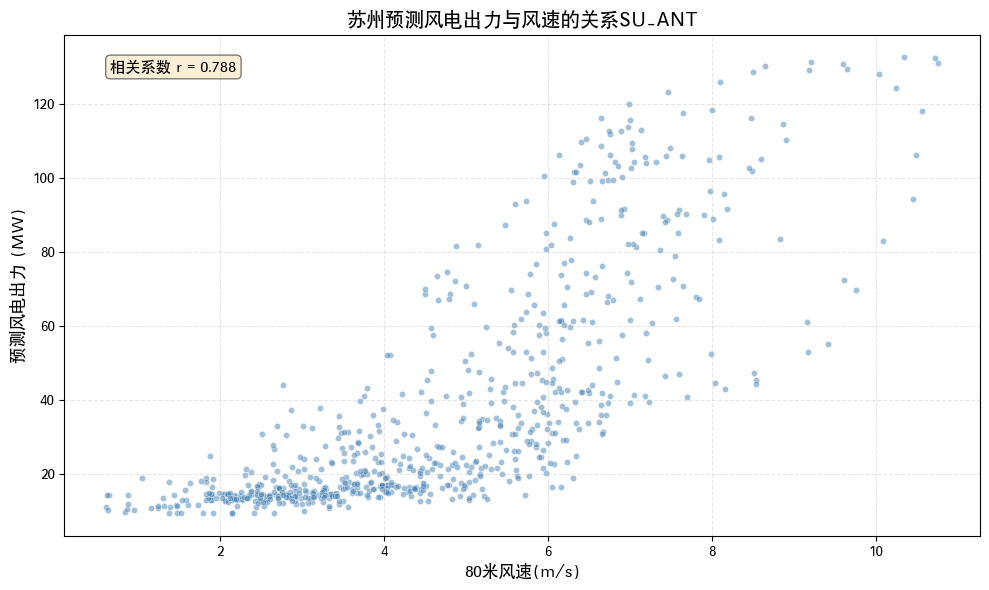

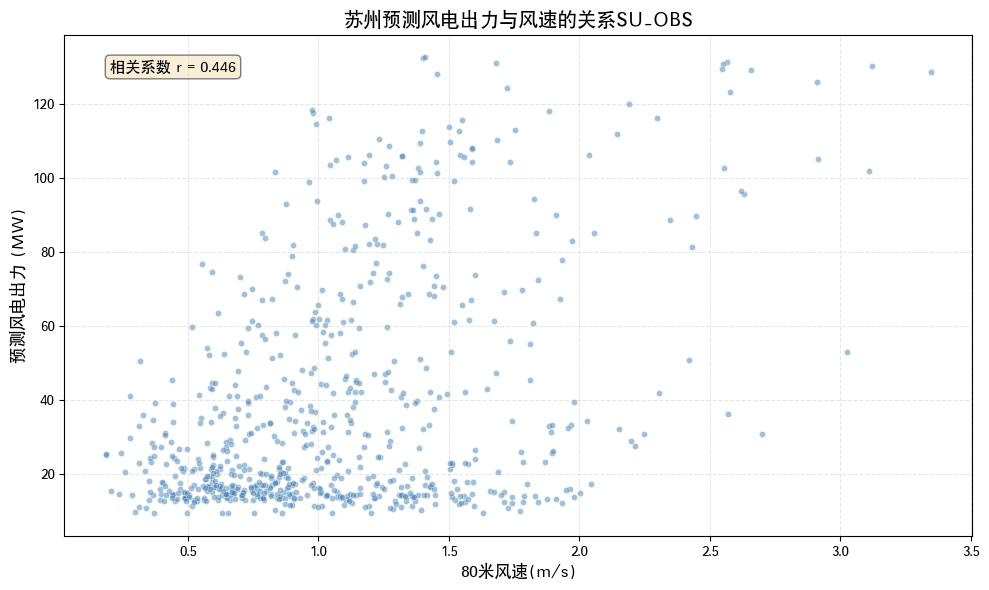

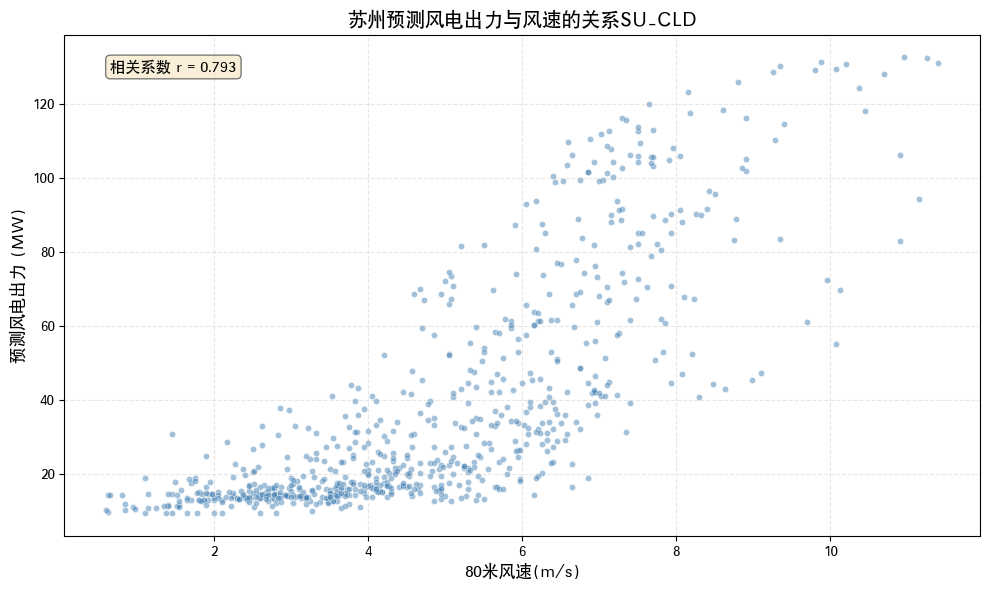

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

file_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江南（苏州）风电气象数据/'
south_df_names = ['SU_ANT', 'SU_OBS', 'SU_CLD']
save_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江南（苏州）风电气象数据/'
os.makedirs(save_path, exist_ok=True)
for name in south_df_names:
    df = pd.read_excel(file_path + f'{name}' + '苏州风电气象数据.xlsx')
    plt.figure(figsize=(10, 6))
    plt.scatter(df['80米风速(m/s)'], df['预测风电江南'], 
            alpha=0.5,        # 透明度
            s=20,             # 点的大小
            c='steelblue',    # 颜色
            edgecolors='white',  # 边缘白色
            linewidth=0.5)
   
    # 添加标签和标题
    plt.xlabel('80米风速(m/s)', fontsize=12)
    plt.ylabel('预测风电出力 (MW)', fontsize=12)
    plt.title('苏州预测风电出力与风速的关系' + f'{name}'  , fontsize=14, fontweight='bold')
    # 添加网格
    plt.grid(True, alpha=0.3, linestyle='--')
    # 显示相关系数
    correlation = df['80米风速(m/s)'].corr(df['预测风电江南'])
    plt.text(0.05, 0.95, f'相关系数 r = {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


    plt.tight_layout()
    plt.savefig(f'{save_path}'+ f'{name}' + '苏州预测风电出力与风速的关系'+'.png', dpi=150, bbox_inches='tight')
    plt.show()

### 江南实际

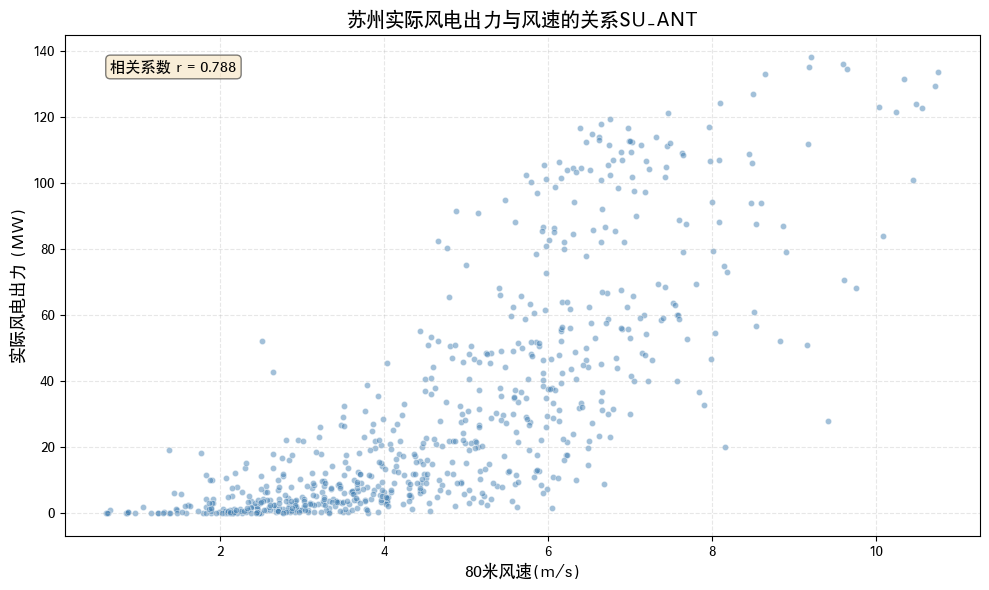

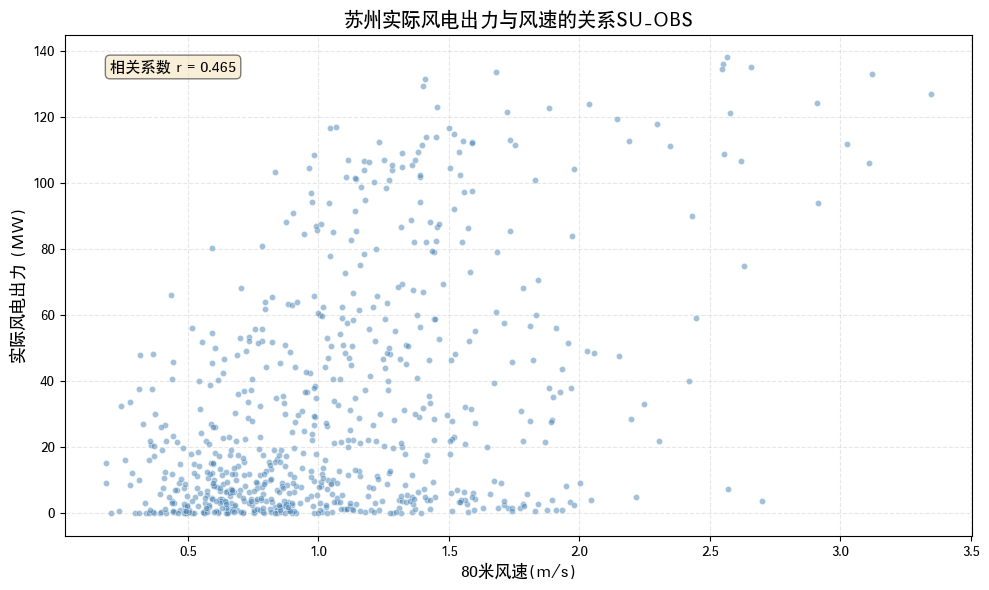

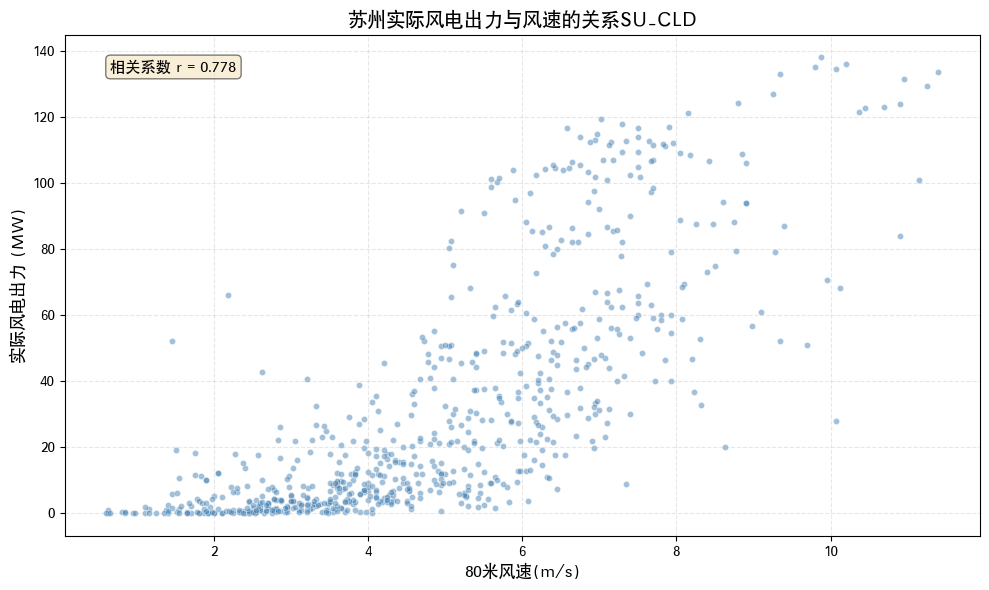

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

file_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江南（苏州）风电气象数据/'
south_df_names = ['SU_ANT', 'SU_OBS', 'SU_CLD']
save_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江南（苏州）风电气象数据/'
os.makedirs(save_path, exist_ok=True)
for name in south_df_names:
    df = pd.read_excel(file_path + f'{name}' + '苏州风电气象数据.xlsx')
    plt.figure(figsize=(10, 6))
    plt.scatter(df['80米风速(m/s)'], df['实际风电江南'], 
            alpha=0.5,        # 透明度
            s=20,             # 点的大小
            c='steelblue',    # 颜色
            edgecolors='white',  # 边缘白色
            linewidth=0.5)
   
    # 添加标签和标题
    plt.xlabel('80米风速(m/s)', fontsize=12)
    plt.ylabel('实际风电出力 (MW)', fontsize=12)
    plt.title('苏州实际风电出力与风速的关系' + f'{name}'  , fontsize=14, fontweight='bold')
    # 添加网格
    plt.grid(True, alpha=0.3, linestyle='--')
    # 显示相关系数
    correlation = df['80米风速(m/s)'].corr(df['实际风电江南'])
    plt.text(0.05, 0.95, f'相关系数 r = {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


    plt.tight_layout()
    plt.savefig(f'{save_path}'+ f'{name}' + '苏州实际风电出力与风速的关系'+'.png', dpi=150, bbox_inches='tight')
    plt.show()

### 江北预测

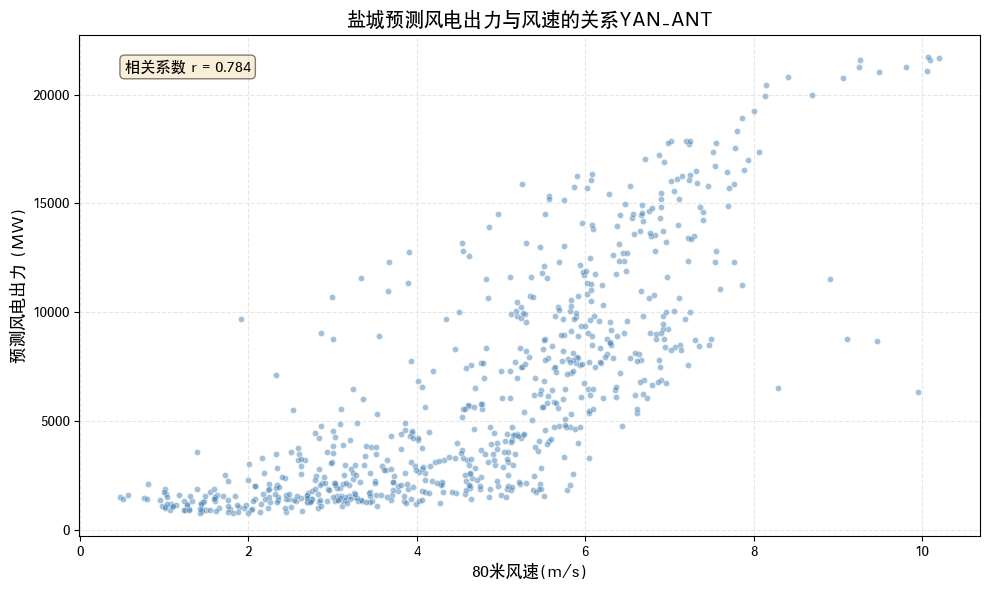

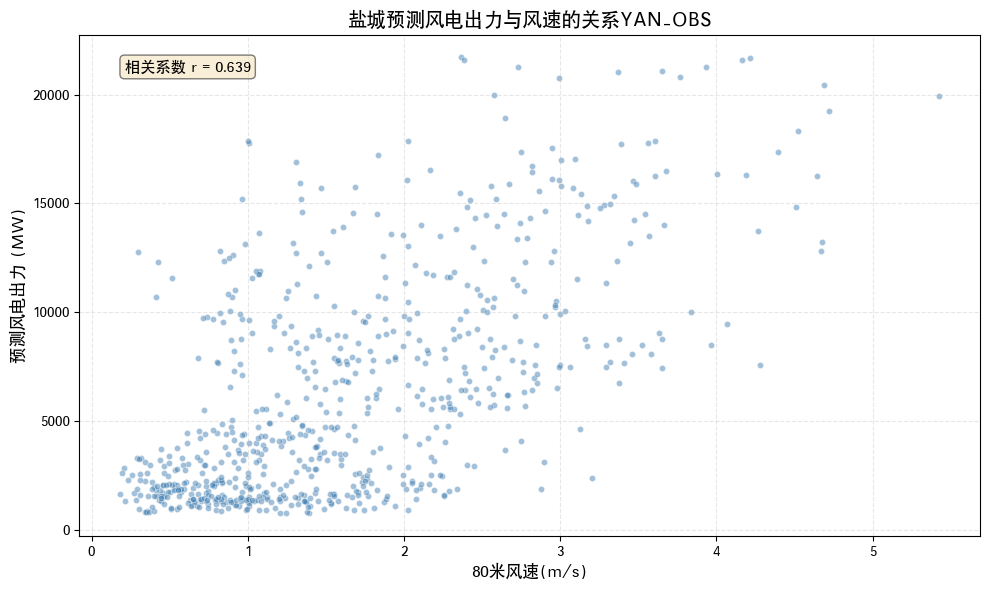

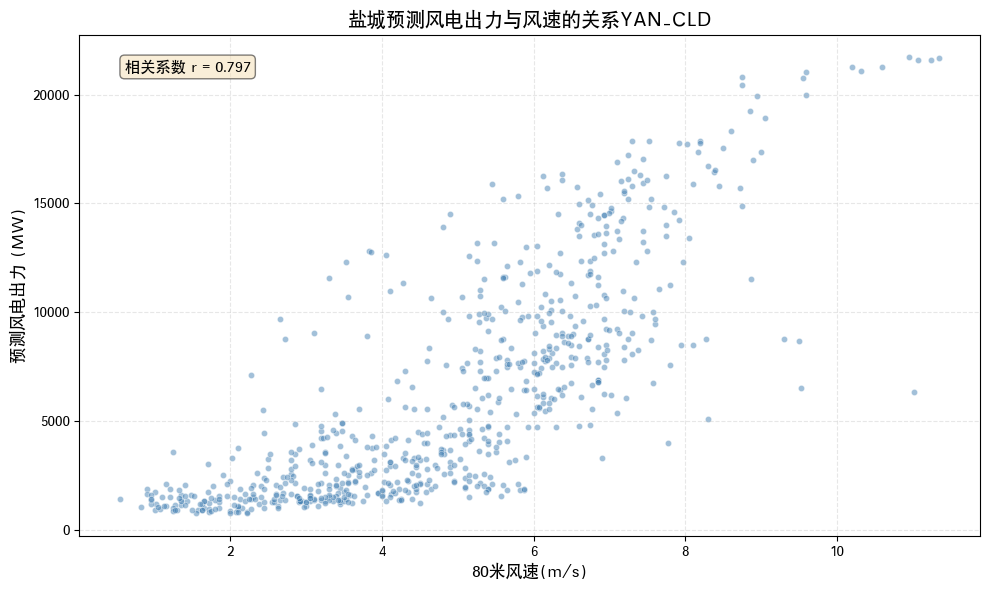

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

file_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）风电气象数据/'
north_df_names = ['YAN_ANT', 'YAN_OBS', 'YAN_CLD']
save_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）风电气象数据/'
os.makedirs(save_path, exist_ok=True)
for name in north_df_names:
    df = pd.read_excel(file_path + f'{name}' + '盐城风电气象数据.xlsx')
    plt.figure(figsize=(10, 6))
    plt.scatter(df['80米风速(m/s)'], df['预测风电江北'], 
            alpha=0.5,        # 透明度
            s=20,             # 点的大小
            c='steelblue',    # 颜色
            edgecolors='white',  # 边缘白色
            linewidth=0.5)
   
    # 添加标签和标题
    plt.xlabel('80米风速(m/s)', fontsize=12)
    plt.ylabel('预测风电出力 (MW)', fontsize=12)
    plt.title('盐城预测风电出力与风速的关系' + f'{name}'  , fontsize=14, fontweight='bold')
    # 添加网格
    plt.grid(True, alpha=0.3, linestyle='--')
    # 显示相关系数
    correlation = df['80米风速(m/s)'].corr(df['预测风电江北'])
    plt.text(0.05, 0.95, f'相关系数 r = {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


    plt.tight_layout()
    plt.savefig(f'{save_path}'+ f'{name}' + '盐城预测风电出力与风速的关系'+'.png', dpi=150, bbox_inches='tight')
    plt.show()

### 江北实际

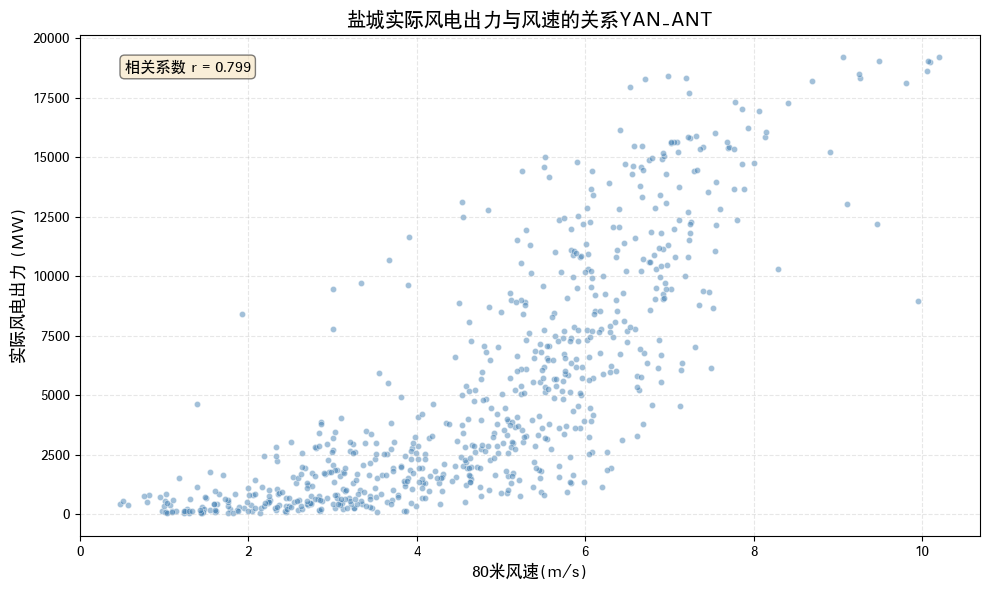

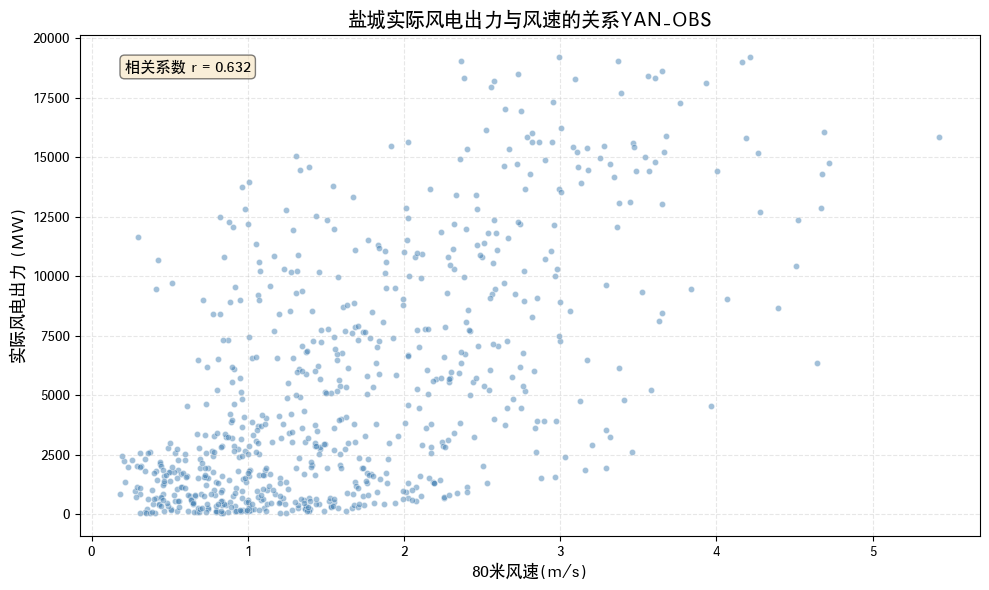

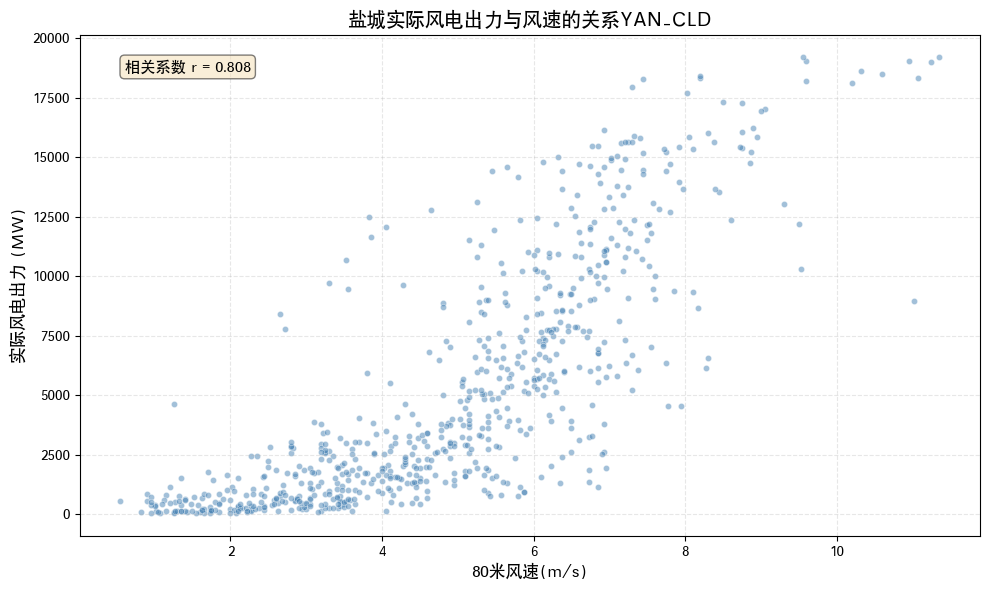

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

file_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）风电气象数据/'
north_df_names = ['YAN_ANT', 'YAN_OBS', 'YAN_CLD']
save_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）风电气象数据/'
os.makedirs(save_path, exist_ok=True)
for name in north_df_names:
    df = pd.read_excel(file_path + f'{name}' + '盐城风电气象数据.xlsx')
    plt.figure(figsize=(10, 6))
    plt.scatter(df['80米风速(m/s)'], df['实际风电江北'], 
            alpha=0.5,        # 透明度
            s=20,             # 点的大小
            c='steelblue',    # 颜色
            edgecolors='white',  # 边缘白色
            linewidth=0.5)
   
    # 添加标签和标题
    plt.xlabel('80米风速(m/s)', fontsize=12)
    plt.ylabel('实际风电出力 (MW)', fontsize=12)
    plt.title('盐城实际风电出力与风速的关系' + f'{name}'  , fontsize=14, fontweight='bold')
    # 添加网格
    plt.grid(True, alpha=0.3, linestyle='--')
    # 显示相关系数
    correlation = df['80米风速(m/s)'].corr(df['实际风电江北'])
    plt.text(0.05, 0.95, f'相关系数 r = {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


    plt.tight_layout()
    plt.savefig(f'{save_path}'+ f'{name}' + '盐城实际风电出力与风速的关系'+'.png', dpi=150, bbox_inches='tight')
    plt.show()

# 说明 ： OBS提供的80米风速存在较为明显的问题，不建议作为价格预测参考